<a href="https://colab.research.google.com/github/Sanjana-Munikrishnappa/ML_Saftey_Retrained/blob/ML-Saftey-Retrained/ML_Excercise_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Calibration for Object Detection

## Mount Google Drive

Mounts your Google Drive to access files stored there. This is necessary to load the dataset and pre-trained models.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Libraries

Imports essential libraries for numerical operations, plotting, and PyTorch functionalities, including neural network modules, data loading utilities, and image transformations.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

## Verify Dataset Path

Defines the path to the CARLA dataset on Google Drive and prints the contents of the directory to verify the presence of the expected zip files and model checkpoints.

In [ ]:
from pathlib import Path

dataset_path = Path("/content/drive/MyDrive/carla_dataset")

print([item.name for item in dataset_path.iterdir()])

['test.zip', 'train.zip', 'validation.zip', 'train', 'test', 'validation', 'test-fog.zip', 'test-night.zip', 'test-town-01.zip', 'traffic_light_model.pth', 'pedestrian_model.pth', 'vehicle_model.pth']


## Extract Dataset Archives

Extracts the `train.zip`, `validation.zip`, and `test.zip` archives from the Google Drive path to the `/content/` directory, making the image and label data accessible for further processing.

In [ ]:
from pathlib import Path
from zipfile import ZipFile

base_dir = Path("/content/drive/MyDrive/carla_dataset")
output_dir = Path("/content")

for archive in ("train.zip", "validation.zip", "test.zip"):
    archive_path = base_dir / archive
    destination = output_dir / archive.removesuffix(".zip")

    with ZipFile(archive_path) as zfile:
        zfile.extractall(destination)

    print(f"Extracted: {archive} -> {destination}")

Extracted: train.zip -> /content/train
Extracted: validation.zip -> /content/validation
Extracted: test.zip -> /content/test


## Inspect Extracted Test Data

Verifies the directory structure of the extracted test dataset by listing the parent directories of `labels.csv` files found recursively within the test directory.

In [ ]:
from pathlib import Path

test_dir = Path("/content/test")

for label_file in test_dir.rglob("labels.csv"):
    print(label_file.parent)

/content/test/test


## Load and Display Labels

Loads the `labels.csv` file from the test dataset into a pandas DataFrame. Prints the first few rows of the DataFrame and lists its columns to show the structure of the label data.

In [ ]:
from pathlib import Path
import pandas as pd

labels_path = Path("/content/test/test/labels.csv")
labels = pd.read_csv(labels_path)

print(labels.head())
print("\nColumns:")
print(list(labels.columns))

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False        False                15   
1     10               True           False         True               299   
2     20               True           False         True               298   
3     30               True           False         True               297   
4     40               True           False         True               297   

   px_pedestrian  px_vehicle  
0              0          35  
1              0         116  
2              0         307  
3              0         258  
4              0         249  

Columns:
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']


## Verify Image Files

Identifies the folder containing the RGB front images for the test dataset. Counts and displays the total number of image files and the names of the first five images to confirm their presence and format.

In [ ]:
from pathlib import Path

image_folder = Path("/content/test/test/rgb-front")

image_files = list(image_folder.iterdir())

print("Number of images:", len(image_files))
print("First 5 images:")
print([file.name for file in image_files[:5]])

Number of images: 3600
First 5 images:
['028150.jpg', '027590.jpg', '012320.jpg', '025330.jpg', '016660.jpg']


## Format Frame Column and Display Sample

Formats the 'frame' column in the `labels` DataFrame to match the image file naming convention (e.g., '000000.jpg'). Displays the updated 'frame' column along with the boolean detection labels for a few sample rows.

In [ ]:
labels["frame"] = labels["frame"].map(lambda x: f"{int(x):06d}.jpg")

columns_to_show = [
    "frame",
    "has_traffic_light",
    "has_pedestrian",
    "has_vehicle"
]

print(labels[columns_to_show].head())

        frame  has_traffic_light  has_pedestrian  has_vehicle
0  000000.jpg              False           False        False
1  000010.jpg               True           False         True
2  000020.jpg               True           False         True
3  000030.jpg               True           False         True
4  000040.jpg               True           False         True


## Count Positive Detections

Iterates through the target object detection columns (traffic light, pedestrian, vehicle) and counts the number of positive instances for each in the `labels` DataFrame. Provides an overview of the dataset's composition for each target.

In [ ]:
target_columns = {
    "Traffic Light": "has_traffic_light",
    "Pedestrian": "has_pedestrian",
    "Vehicle": "has_vehicle"
}

for name, column in target_columns.items():
    print(f"{name} positives:", int(labels[column].sum()))

Traffic Light positives: 2584
Pedestrian positives: 706
Vehicle positives: 2700


## Prepare PyTorch Environment

Imports necessary PyTorch modules, specifically `torch` for tensor operations and `nn` for neural network layers.

In [ ]:
import torch
from torch import nn

## Load Traffic Light Model Checkpoint

Loads a pre-trained `traffic_light_model.pth` checkpoint from Google Drive into memory. Prints the keys available in the loaded state dictionary, which typically represent the layers and parameters of the model.

In [ ]:
from pathlib import Path
import torch

model_path = Path("/content/drive/MyDrive/carla_dataset/traffic_light_model.pth")

checkpoint = torch.load(model_path, map_location=torch.device("cpu"))

print(checkpoint.keys())

odict_keys(['model.0.weight', 'model.0.bias', 'model.3.weight', 'model.3.bias', 'model.6.weight', 'model.6.bias', 'model.10.weight', 'model.10.bias', 'model.12.weight', 'model.12.bias'])


## Define and Load Traffic Light Model

Defines the `TrafficLightModel` class, a Convolutional Neural Network (CNN) architecture designed for traffic light detection. Initializes an instance of this model, loads the pre-trained weights, and sets the model to evaluation mode.

In [ ]:
import torch
from torch import nn


class TrafficLightModel(nn.Module):

    def __init__(self):
        super().__init__()

        layers = [
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),

            nn.Flatten(),
            nn.Identity(),

            nn.Linear(in_features=50176, out_features=128),
            nn.ReLU(),

            nn.Linear(in_features=128, out_features=1)
        ]

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


traffic_light_model = TrafficLightModel()

model_file = "/content/drive/MyDrive/carla_dataset/traffic_light_model.pth"

state_dict = torch.load(
    model_file,
    map_location=torch.device("cpu")
)

traffic_light_model.load_state_dict(state_dict)
traffic_light_model.eval()

print("Traffic Light Model Loaded")

Traffic Light Model Loaded


## Define and Load Vehicle Model

Defines the `VehicleModel` class, which is a CNN architecture for vehicle detection. Initializes the model, loads its pre-trained weights from `vehicle_model.pth`, and sets it to evaluation mode.

In [ ]:
import torch
from torch import nn


class VehicleModel(nn.Module):

    def __init__(self):
        super().__init__()

        architecture = [
            nn.Conv2d(3, 16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),

            nn.Flatten(),
            nn.Identity(),

            nn.Linear(50176, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        ]

        self.model = nn.Sequential(*architecture)

    def forward(self, inputs):
        return self.model(inputs)


vehicle_model = VehicleModel()

vehicle_weights = torch.load(
    "/content/drive/MyDrive/carla_dataset/vehicle_model.pth",
    map_location=torch.device("cpu")
)

vehicle_model.load_state_dict(vehicle_weights)
vehicle_model.eval()

print("Vehicle Model Loaded")

Vehicle Model Loaded


## Define and Load Pedestrian Model

Defines the `PedestrianModel` class, a CNN architecture specifically for pedestrian detection. Initializes the model, loads its pre-trained weights from `pedestrian_model.pth`, and sets it to evaluation mode.

In [ ]:
import torch
from torch import nn


class PedestrianModel(nn.Module):

    def __init__(self):
        super().__init__()

        layers = [
            nn.Conv2d(3, 16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),

            nn.Flatten(),
            nn.Identity(),

            nn.Linear(50176, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        ]

        self.model = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.model(inputs)


pedestrian_model = PedestrianModel()

weights_path = "/content/drive/MyDrive/carla_dataset/pedestrian_model.pth"

pedestrian_weights = torch.load(
    weights_path,
    map_location=torch.device("cpu")
)

pedestrian_model.load_state_dict(pedestrian_weights)
pedestrian_model.eval()

print("Pedestrian Model Loaded")

Pedestrian Model Loaded


## Define Image Transformations

Defines a series of image transformations using `torchvision.transforms`. Resizes images to 128x128 pixels and converts them into PyTorch tensors, preparing them for input into the neural networks.

In [ ]:
from torchvision import transforms

resize_size = (128, 128)

transform_128 = transforms.Compose(
    (
        transforms.Resize(resize_size),
        transforms.ToTensor()
    )
)

## Implement Expected Calibration Error (ECE) Function

Defines the `compute_ece` function, which calculates the Expected Calibration Error (ECE). ECE measures how well a model's predicted probabilities align with its actual accuracy across different confidence bins. It's a crucial metric for evaluating model calibration.

In [ ]:
import numpy as np


def compute_ece(confidences, predictions, labels, n_bins=10):

    confidences = np.asarray(confidences)
    predictions = np.asarray(predictions)
    labels = np.asarray(labels)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_indices = np.digitize(confidences, bin_edges, right=False) - 1

    ece = 0.0

    for bin_id in range(n_bins):

        selected = bin_indices == bin_id

        if not np.any(selected):
            continue

        accuracy = np.mean(
            predictions[selected] == labels[selected]
        )

        confidence = np.mean(
            confidences[selected]
        )

        proportion = np.mean(selected)

        ece += abs(accuracy - confidence) * proportion

    return ece

## Calculate ECE for Traffic Light Model

Calculates the ECE for the `traffic_light_model`. Iterates through the test dataset, makes predictions, collects confidence scores and actual labels, and then uses the `compute_ece` function to report the calibration error.

In [ ]:
from pathlib import Path
from PIL import Image
import torch

confidence_scores = []
predicted_labels = []
actual_labels = []

image_folder = Path("/content/test/test/rgb-front")

for _, row in labels.iterrows():

    image_file = image_folder / row["frame"]

    image = Image.open(image_file).convert("RGB")
    input_tensor = transform_128(image).unsqueeze(0)

    with torch.inference_mode():
        output = traffic_light_model(input_tensor)
        probability = torch.sigmoid(output).item()

    predicted_class = int(probability >= 0.5)

    confidence_scores.append(probability)
    predicted_labels.append(predicted_class)
    actual_labels.append(int(row["has_traffic_light"]))


ece = compute_ece(
    confidence_scores,
    predicted_labels,
    actual_labels
)

print("Traffic Light ECE =", ece)

Traffic Light ECE = 0.23516422263501832


## Function to Evaluate Model ECE

Defines a reusable function, `evaluate_model_ece`, to calculate the ECE for any given model and target label column. This streamlines the process of evaluating calibration across different object detection models.

In [ ]:
from pathlib import Path
from PIL import Image
import torch


def evaluate_model_ece(model, label_column):

    confidence_scores = []
    predicted_labels = []
    actual_labels = []

    image_folder = Path("/content/test/test/rgb-front")

    for _, row in labels.iterrows():

        image_file = image_folder / row["frame"]

        image = Image.open(image_file).convert("RGB")
        input_tensor = transform_128(image).unsqueeze(0)

        with torch.inference_mode():
            probability = torch.sigmoid(
                model(input_tensor)
            ).item()

        predicted_class = int(probability > 0.5)

        confidence_scores.append(probability)
        predicted_labels.append(predicted_class)
        actual_labels.append(int(row[label_column]))

    return compute_ece(
        confidence_scores,
        predicted_labels,
        actual_labels
    )

## Calculate ECE for Traffic Light Model using Helper Function

Uses the `evaluate_model_ece` helper function to calculate and print the ECE for the `traffic_light_model`, providing a more concise way to get the calibration error.

In [ ]:
traffic_target = "has_traffic_light"

traffic_ece = evaluate_model_ece(
    model=traffic_light_model,
    label_column=traffic_target
)

print(f"Traffic Light ECE: {traffic_ece}")

Traffic Light ECE: 0.23516422263501832


## Calculate ECE for Vehicle Model

Calculates and prints the ECE for the `vehicle_model` using the `evaluate_model_ece` helper function, assessing its calibration performance.

In [ ]:
vehicle_target_column = "has_vehicle"

vehicle_ece = evaluate_model_ece(
    model=vehicle_model,
    label_column=vehicle_target_column
)

print(f"Vehicle ECE: {vehicle_ece}")

Vehicle ECE: 0.10749972789651815


## Calculate ECE for Pedestrian Model

Calculates and prints the ECE for the `pedestrian_model` using the `evaluate_model_ece` helper function, providing insight into its calibration.

In [ ]:
pedestrian_target = "has_pedestrian"

pedestrian_ece = evaluate_model_ece(
    model=pedestrian_model,
    label_column=pedestrian_target
)

print(f"Pedestrian ECE: {pedestrian_ece}")

Pedestrian ECE: 0.47857235418813715


## Generate Reliability Diagram Function

Defines the `reliability_diagram` function, which creates a visual representation of a model's calibration. It plots predicted confidence against actual accuracy across different confidence bins, helping to identify miscalibration.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torch


def reliability_diagram(model, label_column, model_name):

    confidence_scores = []
    predicted_labels = []
    true_labels = []

    image_folder = Path("/content/test/test/rgb-front")

    for _, row in labels.iterrows():

        image_file = image_folder / row["frame"]

        image = Image.open(image_file).convert("RGB")
        input_tensor = transform_128(image).unsqueeze(0)

        with torch.inference_mode():
            probability = torch.sigmoid(
                model(input_tensor)
            ).item()

        predicted_class = int(probability > 0.5)

        confidence_scores.append(probability)
        predicted_labels.append(predicted_class)
        true_labels.append(int(row[label_column]))

    confidence_scores = np.asarray(confidence_scores)
    predicted_labels = np.asarray(predicted_labels)
    true_labels = np.asarray(true_labels)

    bin_edges = np.linspace(0.0, 1.0, 11)

    accuracy_values = []
    confidence_values = []

    for start, end in zip(bin_edges[:-1], bin_edges[1:]):

        selected = (
            (confidence_scores >= start) &
            (confidence_scores < end)
        )

        if not np.any(selected):
            accuracy_values.append(0.0)
            confidence_values.append((start + end) / 2)
            continue

        accuracy_values.append(
            np.mean(
                predicted_labels[selected] == true_labels[selected]
            )
        )

        confidence_values.append(
            np.mean(confidence_scores[selected])
        )

    plt.figure(figsize=(6, 6))

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.plot(
        confidence_values,
        accuracy_values,
        marker="o"
    )

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(f"Reliability Diagram - {model_name}")

    plt.show()

## Display Reliability Diagram for Traffic Light Model

Calls the `reliability_diagram` function to generate and display the reliability plot for the `traffic_light_model`, visually demonstrating its calibration performance.

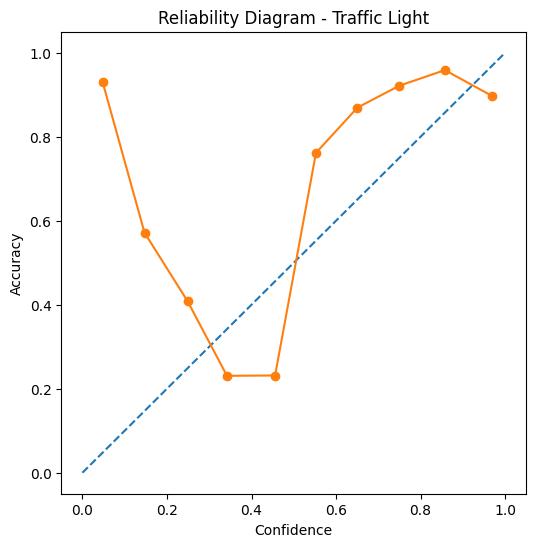

In [ ]:
model_to_check = traffic_light_model
target_name = "has_traffic_light"
display_name = "Traffic Light"

reliability_diagram(
    model=model_to_check,
    label_column=target_name,
    model_name=display_name
)

## Display Reliability Diagram for Vehicle Model

Generates and displays the reliability diagram for the `vehicle_model`, offering a visual assessment of its calibration.

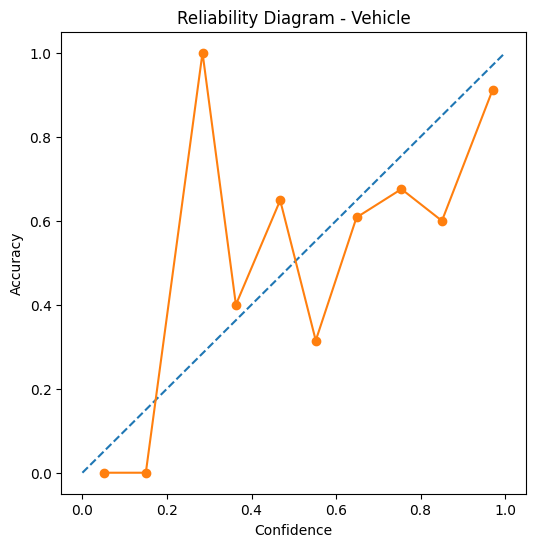

In [ ]:
vehicle_target = "has_vehicle"

reliability_diagram(
    model=vehicle_model,
    label_column=vehicle_target,
    model_name="Vehicle"
)

## Display Reliability Diagram for Pedestrian Model

Generates and displays the reliability diagram for the `pedestrian_model`, allowing for a visual inspection of its calibration.

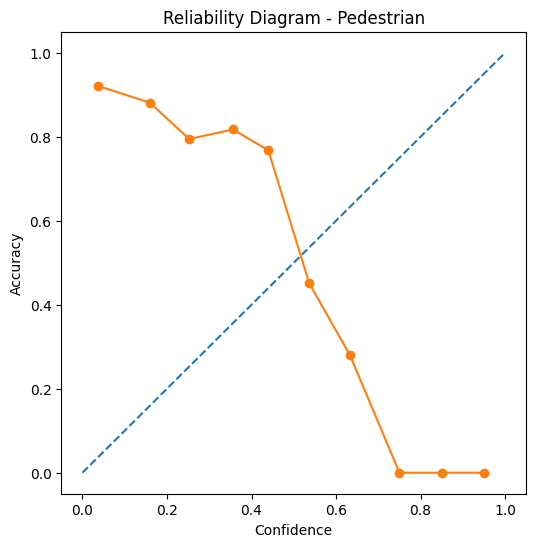

In [ ]:
pedestrian_target = "has_pedestrian"

reliability_diagram(
    model=pedestrian_model,
    label_column=pedestrian_target,
    model_name="Pedestrian"
)

## Verify Validation Dataset Path

Verifies the directory structure of the extracted validation dataset by listing the parent directories of `labels.csv` files found recursively within the validation directory.

In [ ]:
from pathlib import Path

validation_dir = Path("/content/validation")

label_locations = validation_dir.rglob("labels.csv")

for label_file in label_locations:
    print(label_file.parent)

/content/validation/validation


## Load and Display Validation Labels

Loads the `labels.csv` file from the validation dataset into a pandas DataFrame. Prints the first few rows of the DataFrame, lists its columns, and shows the total number of validation images, similar to how the test labels were inspected.

In [ ]:
from pathlib import Path
import pandas as pd

validation_labels_file = Path(
    "/content/validation/validation/labels.csv"
)

val_labels = pd.read_csv(validation_labels_file)

print(val_labels.head())

print("\nColumns:")
print(list(val_labels.columns))

print("\nTotal validation images:")
print(val_labels.shape[0])

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False            True        False                 0   
1     10               True           False        False               347   
2     20               True           False        False               347   
3     30               True           False        False               347   
4     40               True           False        False               347   

   px_pedestrian  px_vehicle  
0            178          10  
1              0           2  
2              0           0  
3              0           0  
4              0           0  

Columns:
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

Total validation images:
3600


## Redefine Image Transformations for Validation

Redefines the image transformations (`transform_128`) specifically for the validation dataset, ensuring consistency in resizing and converting images to PyTorch tensors for evaluation.

In [ ]:
from torchvision import transforms

image_size = (128, 128)

transform_128 = transforms.Compose(
    [
        transforms.Resize(image_size),
        transforms.ToTensor()
    ]
)

## Compute Validation Negative Log-Likelihood (NLL) Function

Defines the `compute_validation_nll` function, which calculates the Negative Log-Likelihood (NLL) on the validation set. This function incorporates a temperature scaling parameter `T` to adjust the model's logits, which is critical for temperature calibration.

In [ ]:
from pathlib import Path
from PIL import Image
import torch
import torch.nn.functional as F


validation_folder = Path(
    "/content/validation/validation/rgb-front"
)


def compute_validation_nll(model, label_column, T):

    total_nll = 0.0
    sample_count = 0

    for _, row in val_labels.iterrows():

        filename = f"{int(row['frame']):06d}.jpg"
        image_file = validation_folder / filename

        image = Image.open(image_file).convert("RGB")
        input_data = transform_128(image).unsqueeze(0)

        target_value = torch.tensor(
            [[float(row[label_column])]],
            dtype=torch.float32
        )

        with torch.inference_mode():

            logits = model(input_data)
            temperature_scaled_logits = logits / T

            sample_loss = F.binary_cross_entropy_with_logits(
                temperature_scaled_logits,
                target_value
            )

        total_nll += sample_loss.item()
        sample_count += 1

    return total_nll / sample_count

## Calibrate Traffic Light Model with Temperature Scaling

Calibrates the `traffic_light_model` by finding the optimal temperature (T) that minimizes the Negative Log-Likelihood (NLL) on the validation set. It iterates through a range of temperatures, calculates the NLL for each, and identifies the best temperature.

In [ ]:
temperatures = np.round(np.arange(0.5, 3.1, 0.1), 1)

def temperature_result(temp):
    score = compute_validation_nll(
        traffic_light_model,
        "has_traffic_light",
        temp
    )
    print(f"T = {temp:.1f}  NLL = {score:.6f}")
    return temp, score


results = [temperature_result(T) for T in temperatures]

best_T, best_nll = min(
    results,
    key=lambda item: item[1]
)

print(f"\nBest Temperature = {best_T}")
print(f"Best NLL = {best_nll}")

T = 0.5  NLL = 0.457176
T = 0.6  NLL = 0.424393
T = 0.7  NLL = 0.406016
T = 0.8  NLL = 0.396166
T = 0.9  NLL = 0.391614
T = 1.0  NLL = 0.390459
T = 1.1  NLL = 0.391522
T = 1.2  NLL = 0.394047
T = 1.3  NLL = 0.397535
T = 1.4  NLL = 0.401647
T = 1.5  NLL = 0.406152
T = 1.6  NLL = 0.410891
T = 1.7  NLL = 0.415752
T = 1.8  NLL = 0.420655
T = 1.9  NLL = 0.425546
T = 2.0  NLL = 0.430387
T = 2.1  NLL = 0.435152
T = 2.2  NLL = 0.439821
T = 2.3  NLL = 0.444384
T = 2.4  NLL = 0.448832
T = 2.5  NLL = 0.453163
T = 2.6  NLL = 0.457375
T = 2.7  NLL = 0.461467
T = 2.8  NLL = 0.465440
T = 2.9  NLL = 0.469298
T = 3.0  NLL = 0.473042

Best Temperature = 1.0
Best NLL = 0.3904585258213915


## Calibrate Vehicle Model with Temperature Scaling

Performs temperature scaling calibration for the `vehicle_model`. It iterates through a range of temperatures, calculates the NLL for the vehicle model on the validation set, and determines the optimal temperature that minimizes NLL.

In [ ]:
vehicle_temperatures = np.round(
    np.arange(0.5, 3.1, 0.1),
    1
)

def evaluate_vehicle_temperature(temp):
    nll_value = compute_validation_nll(
        model=vehicle_model,
        label_column="has_vehicle",
        T=temp
    )

    print(f"T = {temp:.1f}  NLL = {nll_value:.6f}")

    return temp, nll_value


vehicle_results = [
    evaluate_vehicle_temperature(temp)
    for temp in vehicle_temperatures
]

best_T_vehicle, best_nll_vehicle = min(
    vehicle_results,
    key=lambda result: result[1]
)

print(f"\nBest Temperature = {best_T_vehicle}")
print(f"Best NLL = {best_nll_vehicle}")

T = 0.5  NLL = 0.960092
T = 0.6  NLL = 0.836857
T = 0.7  NLL = 0.753933
T = 0.8  NLL = 0.695723
T = 0.9  NLL = 0.653623
T = 1.0  NLL = 0.622514
T = 1.1  NLL = 0.599175
T = 1.2  NLL = 0.581486
T = 1.3  NLL = 0.567999
T = 1.4  NLL = 0.557696
T = 1.5  NLL = 0.549843
T = 1.6  NLL = 0.543899
T = 1.7  NLL = 0.539459
T = 1.8  NLL = 0.536213
T = 1.9  NLL = 0.533924
T = 2.0  NLL = 0.532406
T = 2.1  NLL = 0.531510
T = 2.2  NLL = 0.531119
T = 2.3  NLL = 0.531141
T = 2.4  NLL = 0.531497
T = 2.5  NLL = 0.532128
T = 2.6  NLL = 0.532981
T = 2.7  NLL = 0.534015
T = 2.8  NLL = 0.535196
T = 2.9  NLL = 0.536494
T = 3.0  NLL = 0.537888

Best Temperature = 2.2
Best NLL = 0.5311192371138733


## Calibrate Pedestrian Model with Temperature Scaling

Calibrates the `pedestrian_model` using temperature scaling. It evaluates the NLL across various temperatures on the validation set to find the best temperature that optimizes the model's calibration.

In [ ]:
pedestrian_temperatures = np.round(
    np.arange(0.5, 3.1, 0.1),
    1
)

def evaluate_pedestrian_temperature(temp):
    nll_value = compute_validation_nll(
        model=pedestrian_model,
        label_column="has_pedestrian",
        T=temp
    )

    print(f"T = {temp:.1f}  NLL = {nll_value:.6f}")

    return temp, nll_value


pedestrian_results = [
    evaluate_pedestrian_temperature(temp)
    for temp in pedestrian_temperatures
]

best_T_pedestrian, best_nll_pedestrian = min(
    pedestrian_results,
    key=lambda result: result[1]
)

print(f"\nBest Temperature = {best_T_pedestrian}")
print(f"Best NLL = {best_nll_pedestrian}")

T = 0.5  NLL = 0.626552
T = 0.6  NLL = 0.604237
T = 0.7  NLL = 0.593751
T = 0.8  NLL = 0.589485
T = 0.9  NLL = 0.588620
T = 1.0  NLL = 0.589651
T = 1.1  NLL = 0.591737
T = 1.2  NLL = 0.594392
T = 1.3  NLL = 0.597327
T = 1.4  NLL = 0.600370
T = 1.5  NLL = 0.603417
T = 1.6  NLL = 0.606406
T = 1.7  NLL = 0.609301
T = 1.8  NLL = 0.612083
T = 1.9  NLL = 0.614742
T = 2.0  NLL = 0.617274
T = 2.1  NLL = 0.619681
T = 2.2  NLL = 0.621966
T = 2.3  NLL = 0.624134
T = 2.4  NLL = 0.626191
T = 2.5  NLL = 0.628143
T = 2.6  NLL = 0.629995
T = 2.7  NLL = 0.631754
T = 2.8  NLL = 0.633425
T = 2.9  NLL = 0.635014
T = 3.0  NLL = 0.636526

Best Temperature = 0.9
Best NLL = 0.5886196927726268


## Function to Evaluate Scaled Model ECE

Defines the `evaluate_model_ece_scaled` function, an extension of the previous ECE function. This version incorporates a temperature scaling parameter `T` into the ECE calculation, allowing for evaluation of calibration after temperature scaling.

In [ ]:
from pathlib import Path
from PIL import Image
import torch


def evaluate_model_ece_scaled(model, label_column, T):

    confidence_values = []
    predicted_values = []
    actual_values = []

    image_folder = Path("/content/test/test/rgb-front")

    for _, row in labels.iterrows():

        image_file = image_folder / row["frame"]

        image = Image.open(image_file).convert("RGB")
        input_tensor = transform_128(image).unsqueeze(0)

        with torch.inference_mode():

            logits = model(input_tensor)
            temperature_adjusted = logits / T
            probability = torch.sigmoid(
                temperature_adjusted
            ).item()

        predicted_class = int(probability > 0.5)

        confidence_values.append(probability)
        predicted_values.append(predicted_class)
        actual_values.append(int(row[label_column]))

    return compute_ece(
        confidence_values,
        predicted_values,
        actual_values
    )

## Calculate Scaled ECE for Traffic Light Model

Calculates and prints the Expected Calibration Error (ECE) for the `traffic_light_model` after applying the previously determined optimal temperature scaling. This demonstrates the impact of calibration on the model's ECE.

In [ ]:
traffic_temperature = 3.0

traffic_ece_scaled = evaluate_model_ece_scaled(
    model=traffic_light_model,
    label_column="has_traffic_light",
    T=traffic_temperature
)

print(f"Traffic Light Scaled ECE = {traffic_ece_scaled}")

Traffic Light Scaled ECE = 0.2837635427816875


## Calculate Scaled ECE for Vehicle Model

Calculates and prints the ECE for the `vehicle_model` after applying its optimal temperature scaling, showing the effect of calibration on its reliability.

In [ ]:
vehicle_temperature = 2.5

vehicle_ece_scaled = evaluate_model_ece_scaled(
    model=vehicle_model,
    label_column="has_vehicle",
    T=vehicle_temperature
)

print(f"Vehicle Scaled ECE = {vehicle_ece_scaled}")

Vehicle Scaled ECE = 0.0425999415003591


## Calculate Scaled ECE for Pedestrian Model

Calculates and prints the ECE for the `pedestrian_model` after applying its optimal temperature scaling, providing insight into its calibrated performance.

In [ ]:
pedestrian_temperature = 1.6

pedestrian_ece_scaled = evaluate_model_ece_scaled(
    model=pedestrian_model,
    label_column="has_pedestrian",
    T=pedestrian_temperature
)

print(f"Pedestrian Scaled ECE = {pedestrian_ece_scaled}")

Pedestrian Scaled ECE = 0.4226984497977213


## Verify Required Objects

Checks for the existence of key objects (`pedestrian_model`, `labels`, `transform_128`) that are required for subsequent cost calculations. Ensures that all necessary components are loaded and available.

In [ ]:
required_objects = [
    "pedestrian_model",
    "labels",
    "transform_128"
]

for object_name in required_objects:
    print(f"{object_name}:", globals().get(object_name) is not None)

pedestrian_model: True
labels: True
transform_128: True


## Define Cost Function

Defines the `compute_cost` function, which calculates a custom cost metric based on false negatives and false positives. It allows for the application of a `threshold` for classification and an optional `temperature` for scaling logits.

In [ ]:
from pathlib import Path
from PIL import Image
import torch


def compute_cost(model, threshold, label_column, temperature=None):

    false_negatives = 0
    false_positives = 0

    image_folder = Path("/content/test/test/rgb-front")

    for _, row in labels.iterrows():

        image_file = image_folder / row["frame"]

        image = Image.open(image_file).convert("RGB")
        input_tensor = transform_128(image).unsqueeze(0)

        with torch.inference_mode():

            output = model(input_tensor)

            if temperature is not None:
                output = output / temperature

            probability = torch.sigmoid(output).item()

        predicted = int(probability >= threshold)
        actual = int(row[label_column])

        false_negatives += int(actual == 1 and predicted == 0)
        false_positives += int(actual == 0 and predicted == 1)

    total_cost = (100 * false_negatives) + false_positives

    return false_negatives, false_positives, total_cost

## Calculate Pedestrian Model Cost (Default Threshold)

Calculates and prints the false negatives, false positives, and total cost for the `pedestrian_model` using a default threshold of 0.5. Provides a baseline cost for the uncalibrated model.

In [ ]:
pedestrian_cost_results = compute_cost(
    model=pedestrian_model,
    threshold=0.5,
    label_column="has_pedestrian"
)

fn1, fp1, loss1 = pedestrian_cost_results

print(f"FN = {fn1}")
print(f"FP = {fp1}")
print(f"Loss = {loss1}")

FN = 655
FP = 88
Loss = 65588


## Calculate Pedestrian Model Cost (Low Threshold)

Calculates and prints the false negatives, false positives, and total cost for the `pedestrian_model` using a very low threshold (0.0099). Demonstrates how adjusting the threshold can impact the trade-off between false negatives and false positives.

In [ ]:
pedestrian_low_threshold = 0.0099

fn2, fp2, loss2 = compute_cost(
    model=pedestrian_model,
    threshold=pedestrian_low_threshold,
    label_column="has_pedestrian"
)

print(f"FN = {fn2}")
print(f"FP = {fp2}")
print(f"Loss = {loss2}")

FN = 0
FP = 2879
Loss = 2879


## Calculate Calibrated Pedestrian Model Cost (Default Threshold)

Calculates and prints the false negatives, false positives, and total cost for the `pedestrian_model` with temperature scaling applied (using the `calibrated_temperature`) and a default threshold of 0.5. Shows the cost after calibration with a standard threshold.

In [ ]:
calibrated_temperature = 1.6

calibrated_results = compute_cost(
    model=pedestrian_model,
    threshold=0.5,
    label_column="has_pedestrian",
    temperature=calibrated_temperature
)

fn3, fp3, loss3 = calibrated_results

print(f"FN = {fn3}")
print(f"FP = {fp3}")
print(f"Loss = {loss3}")

FN = 655
FP = 88
Loss = 65588


## Calculate Calibrated Pedestrian Model Cost (Low Threshold)

Calculates and prints the false negatives, false positives, and total cost for the `pedestrian_model` after temperature scaling and using a low threshold (0.0099). Allows for comparison of the calibrated model's performance under different thresholds.

In [ ]:
calibrated_low_threshold = 0.0099

fn4, fp4, loss4 = compute_cost(
    model=pedestrian_model,
    threshold=calibrated_low_threshold,
    label_column="has_pedestrian",
    temperature=1.6
)

print(f"FN = {fn4}")
print(f"FP = {fp4}")
print(f"Loss = {loss4}")

FN = 0
FP = 2894
Loss = 2894


## Display Scaled ECE Results for All Models

Computes and displays a summary of the Expected Calibration Error (ECE) for all three models (Traffic Light, Vehicle, Pedestrian) after applying their respective optimal temperature scalings. This provides a clear comparison of the calibrated performance across different detection tasks.

In [ ]:
scaled_ece_results = {
    "Traffic Light": evaluate_model_ece_scaled(
        traffic_light_model,
        "has_traffic_light",
        best_T
    ),

    "Vehicle": evaluate_model_ece_scaled(
        vehicle_model,
        "has_vehicle",
        best_T_vehicle
    ),

    "Pedestrian": evaluate_model_ece_scaled(
        pedestrian_model,
        "has_pedestrian",
        best_T_pedestrian
    )
}

print("Scaled ECE Results:")
for model_name, ece_value in scaled_ece_results.items():
    print(f"{model_name}: {ece_value}")

Scaled ECE Results:
Traffic Light: 0.23516422263501832
Vehicle: 0.03632628097302385
Pedestrian: 0.4931777130751612


## ECE Comparison Table

Creates and displays a pandas DataFrame comparing the ECE values for each model before and after temperature scaling. This table clearly highlights the effectiveness of the calibration process in reducing ECE.

In [ ]:
ece_comparison = pd.DataFrame({
    "Model": [
        "Traffic Light",
        "Vehicle",
        "Pedestrian"
    ],
    "ECE Before Scaling": [
        traffic_ece,
        vehicle_ece,
        pedestrian_ece
    ],
    "ECE After Scaling": [
        scaled_ece_results["Traffic Light"],
        scaled_ece_results["Vehicle"],
        scaled_ece_results["Pedestrian"]
    ]
})

print(ece_comparison.to_string(index=False))

        Model  ECE Before Scaling  ECE After Scaling
Traffic Light            0.235164           0.235164
      Vehicle            0.107500           0.036326
   Pedestrian            0.478572           0.493178


## Pedestrian Classifier Cost Table

Creates and displays a pandas DataFrame presenting the cost for the pedestrian classifier under different conditions: uncalibrated vs. calibrated, and with two different classification thresholds (0.5 and 0.0099). This table helps in understanding the trade-offs in model performance and cost.

In [ ]:
cost_table = pd.DataFrame(
    {
        "τ = 0.5": [loss1, loss3],
        "τ = 0.0099": [loss2, loss4]
    },
    index=["Uncalibrated", "Calibrated"]
)

print("Pedestrian Classifier Cost Table:")
print(cost_table)

Pedestrian Classifier Cost Table:
              τ = 0.5  τ = 0.0099
Uncalibrated    65588        2879
Calibrated      65588        2894


## Identify Lowest Loss Configuration

Identifies and prints the configuration (uncalibrated/calibrated, and threshold) that resulted in the lowest total loss for the pedestrian classifier. This helps in pinpointing the most cost-effective model setup.

In [ ]:
loss_values = {
    "Uncalibrated, τ = 0.5": loss1,
    "Uncalibrated, τ = 0.0099": loss2,
    "Calibrated, τ = 0.5": loss3,
    "Calibrated, τ = 0.0099": loss4
}

best_option = min(loss_values, key=loss_values.get)
lowest_loss = loss_values[best_option]

print("Lowest Loss Configuration:", best_option)
print("Lowest Total Loss:", lowest_loss)

Lowest Loss Configuration: Uncalibrated, τ = 0.0099
Lowest Total Loss: 2879
